In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SWING

In [2]:
header_list = ["Cause Gene", "Effect Gene", "mean_importance"]
gold_standard = {}
Nodes = [10, 20, 50, 100]
step = 10

mean_important_array_SWING = {}
mean_important_array_rand_SWING = {}
mean_important_array_crand_SWING = {}

mean_important_array_dynGENIE3 = {}
mean_important_array_rand_dynGENIE3 = {}
mean_important_array_crand_dynGENIE3 = {}

for nodes in Nodes:
    
    mean_important_array_SWING[f"mean_important_array_SWING_{nodes}"] = np.array([])
    mean_important_array_rand_SWING[f"mean_important_array_rand_SWING_{nodes}"] = np.array([])
    mean_important_array_crand_SWING[f"mean_important_array_crand_SWING_{nodes}"] = np.array([])
    
    mean_important_array_dynGENIE3[f"mean_important_array_dynGENIE3_{nodes}"] = np.array([])
    mean_important_array_rand_dynGENIE3[f"mean_important_array_rand_dynGENIE3_{nodes}"] = np.array([])
    mean_important_array_crand_dynGENIE3[f"mean_important_array_crand_dynGENIE3_{nodes}"] = np.array([])
   
    for instance in range(100):
        
        instance = instance + 1
        
        mean_importance_file_SWING = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t")
        mean_importance_file_SWING_rand = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_SWING_{instance}_rand.tsv", sep ="\t")
        mean_importance_file_SWING_crand = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_SWING_{instance}_crand.tsv", sep ="\t")
        
        if (nodes == 10) | (nodes == 20):
            mean_importance_file_dynGENIE3= pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])
        else:
            mean_importance_file_dynGENIE3= pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}.tsv", sep ="\t", names = ["Cause Gene", "Effect Gene", "mean_importance"]).sort_values(by=["Cause Gene", "Effect Gene"])
        mean_importance_file_dynGENIE3_rand = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list)
        mean_importance_file_dynGENIE3_crand = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_dynGENIE3_{instance}_crand.tsv", sep ="\t", names = header_list)
    
        mean_important_array_SWING[f"mean_important_array_SWING_{nodes}"] = np.append(mean_important_array_SWING[f"mean_important_array_SWING_{nodes}"], mean_importance_file_SWING[f"mean_importance"].values)
        mean_important_array_rand_SWING[f"mean_important_array_rand_SWING_{nodes}"] = np.append(mean_important_array_rand_SWING[f"mean_important_array_rand_SWING_{nodes}"], mean_importance_file_SWING_rand[f"mean_importance"].values)
        mean_important_array_crand_SWING[f"mean_important_array_crand_SWING_{nodes}"] = np.append(mean_important_array_crand_SWING[f"mean_important_array_crand_SWING_{nodes}"], mean_importance_file_SWING_crand[f"mean_importance"].values)
        
        mean_important_array_dynGENIE3[f"mean_important_array_dynGENIE3_{nodes}"] = np.append(mean_important_array_dynGENIE3[f"mean_important_array_dynGENIE3_{nodes}"], mean_importance_file_dynGENIE3[f"mean_importance"].values)
        mean_important_array_rand_dynGENIE3[f"mean_important_array_rand_dynGENIE3_{nodes}"] = np.append(mean_important_array_rand_dynGENIE3[f"mean_important_array_rand_dynGENIE3_{nodes}"], mean_importance_file_dynGENIE3_rand[f"mean_importance"].values)
        mean_important_array_crand_dynGENIE3[f"mean_important_array_crand_dynGENIE3_{nodes}"] = np.append(mean_important_array_crand_dynGENIE3[f"mean_important_array_crand_dynGENIE3_{nodes}"], mean_importance_file_dynGENIE3_crand[f"mean_importance"].values)
        
        

# Histogram 10 genes

## SWING

mean:  0.024544706386615055
mean rand:  0.03011604722583283
estandard desv:  0.021523511557564462
estandard desv rand:  0.01221058454365925
most frequent value:  0.1375408047486198   46.212405023257794
most frequent value rand:  0.1132993569697565   44.34774156496694


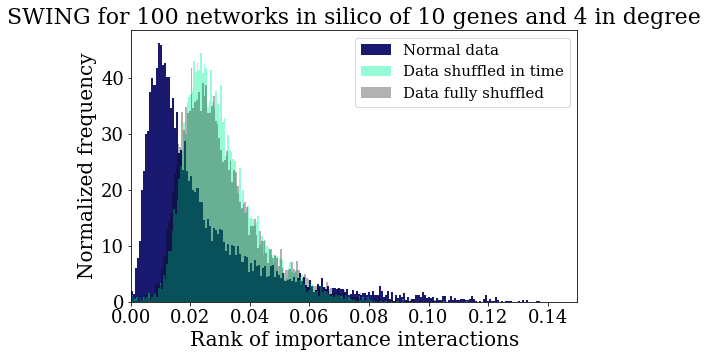

In [8]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_SWING["mean_important_array_SWING_10"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_SWING["mean_important_array_rand_SWING_10"], bins = 200, color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_SWING["mean_important_array_crand_SWING_10"], bins = 200, color='k', alpha = 0.3, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20)
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("SWING for 100 networks in silico of 10 genes and 4 in degree", fontsize = 22)
plt.xlim(0,0.15)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_SWING["mean_important_array_SWING_10"].mean())
print("mean rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_10"].mean())
print("estandard desv: ", mean_important_array_SWING["mean_important_array_SWING_10"].std())
print("estandard desv rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_10"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

## dynGENIE3

mean:  0.11100000366666667
mean rand:  0.11100000133333333
estandard desv:  0.0666277717934787
estandard desv rand:  0.044842031817810775
most frequent value:  0.488905   10.272388750825302
most frequent value rand:  0.485511   16.06554743352881


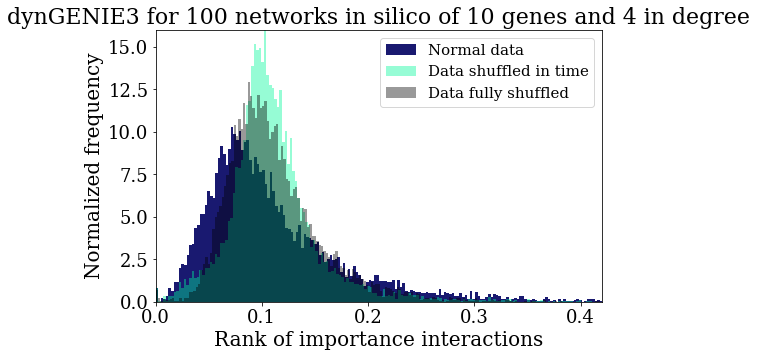

In [9]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_10"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_10"], bins = 200,color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_dynGENIE3["mean_important_array_crand_dynGENIE3_10"], bins = 200,color='k', alpha = 0.4, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20, family = "serif")
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("dynGENIE3 for 100 networks in silico of 10 genes and 4 in degree", fontsize = 22)
plt.xlim(0,0.42)
plt.ylim(0,16)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_10"].mean())
print("mean rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_10"].mean())
print("estandard desv: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_10"].std())
print("estandard desv rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_10"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

# Histogram 20 genes

## SWING

mean:  0.01322201804700822
mean rand:  0.015453409949599622
estandard desv:  0.013638958358355444
estandard desv rand:  0.007790891350037197
most frequent value:  0.1123610496310822   95.85326081919958
most frequent value rand:  0.0967294247131483   82.27361665682874


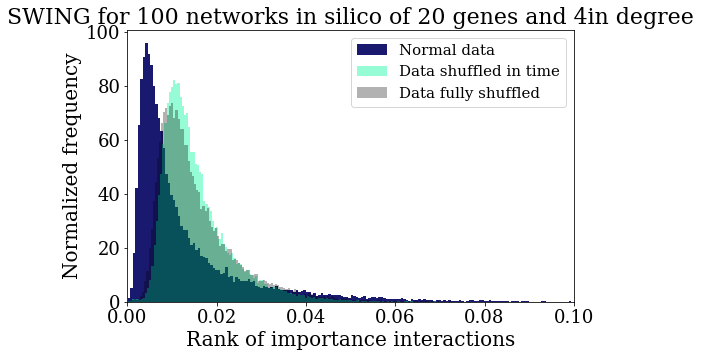

In [10]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_SWING["mean_important_array_SWING_20"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_SWING["mean_important_array_rand_SWING_20"], bins = 200, color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_SWING["mean_important_array_crand_SWING_20"], bins = 200, color='k', alpha = 0.3, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20)
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("SWING for 100 networks in silico of 20 genes and 4in degree", fontsize = 22)
plt.xlim(0,0.1)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_SWING["mean_important_array_SWING_20"].mean())
print("mean rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_20"].mean())
print("estandard desv: ", mean_important_array_SWING["mean_important_array_SWING_20"].std())
print("estandard desv rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_20"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

## dynGENIE3

mean:  0.05260526276315789
mean rand:  0.05263157710526316
estandard desv:  0.037216979284434605
estandard desv rand:  0.024083321023459413
most frequent value:  0.426307   21.235005709376935
most frequent value rand:  0.32012   28.721840251922618


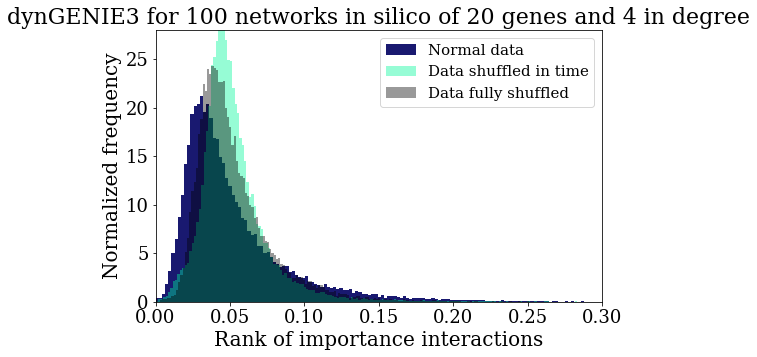

In [11]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_20"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_20"], bins = 200,color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_dynGENIE3["mean_important_array_crand_dynGENIE3_20"], bins = 200,color='k', alpha = 0.4, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20, family = "serif")
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("dynGENIE3 for 100 networks in silico of 20 genes and 4 in degree", fontsize = 22)
plt.xlim(0,0.3)
plt.ylim(0,28)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_20"].mean())
print("mean rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_20"].mean())
print("estandard desv: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_20"].std())
print("estandard desv rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_20"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

# Histogram 50 genes

## SWING

mean:  0.005673591143618848
mean rand:  0.006360461071643319
estandard desv:  0.007418268037495439
estandard desv rand:  0.004181064135552022
most frequent value:  0.0824420067202825   269.4881376738366
most frequent value rand:  0.0525482185966887   198.59699616923916


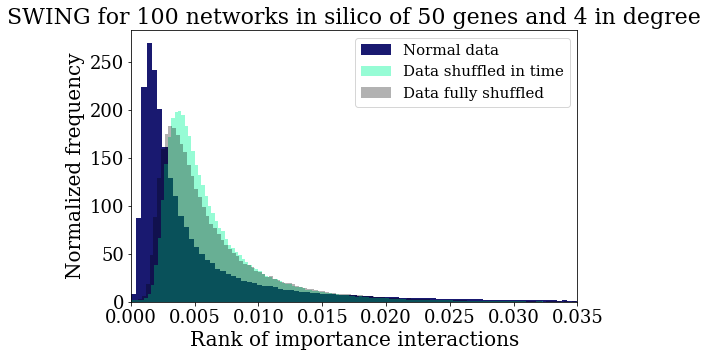

In [12]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_SWING["mean_important_array_SWING_50"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_SWING["mean_important_array_rand_SWING_50"], bins = 200, color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_SWING["mean_important_array_crand_SWING_50"], bins = 200, color='k', alpha = 0.3, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20)
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("SWING for 100 networks in silico of 50 genes and 4 in degree", fontsize = 22)
plt.xlim(0,0.035)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_SWING["mean_important_array_SWING_50"].mean())
print("mean rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_50"].mean())
print("estandard desv: ", mean_important_array_SWING["mean_important_array_SWING_50"].std())
print("estandard desv rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_50"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

## dynGENIE3

mean:  0.02040408189795918
mean rand:  0.02040408126122449
estandard desv:  0.018748205278822403
estandard desv rand:  0.012865672380585792
most frequent value:  0.259743   57.41625140140483
most frequent value rand:  0.208385   64.96217509486213


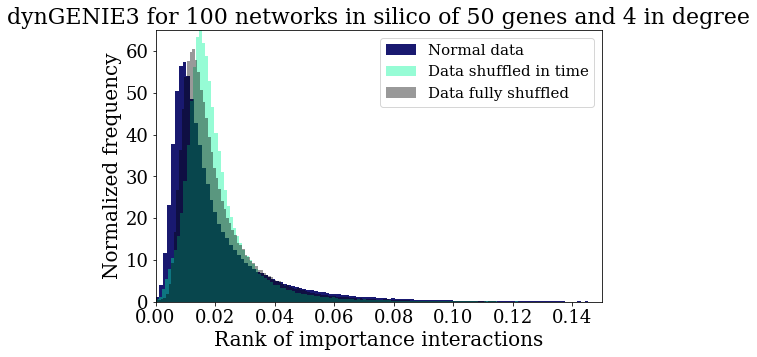

In [13]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_50"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_50"], bins = 200,color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_dynGENIE3["mean_important_array_crand_dynGENIE3_50"], bins = 200,color='k', alpha = 0.4, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20, family = "serif")
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("dynGENIE3 for 100 networks in silico of 50 genes and 4 in degree", fontsize = 22)
plt.xlim(0,0.15)
plt.ylim(0,65)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_50"].mean())
print("mean rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_50"].mean())
print("estandard desv: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_50"].std())
print("estandard desv rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_50"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

# Histogram 100 genes

In [3]:
file_path_data = "C:/Users/ivana/OneDrive/Desktop/Imagenes Internship"

## SWING

mean:  0.0029810930449313414
mean rand:  0.003234173879084176
estandard desv:  0.0044727880628651516
estandard desv rand:  0.0024719215205112545
most frequent value:  0.0678911188320478   503.762656074759
most frequent value rand:  0.0430968006521292   386.31546367901285


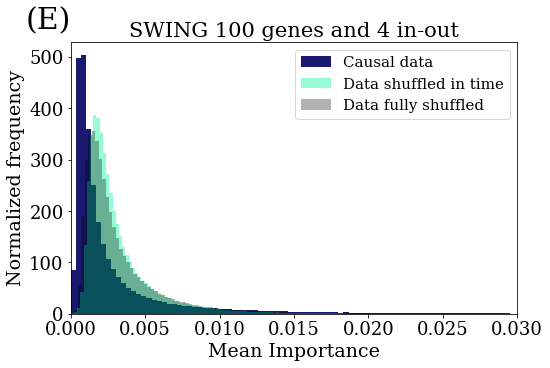

In [4]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_SWING["mean_important_array_SWING_100"], bins = 200, color = "midnightblue", density =1, label = r"Causal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_SWING["mean_important_array_rand_SWING_100"], bins = 200, color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_SWING["mean_important_array_crand_SWING_100"], bins = 200, color='k', alpha = 0.3, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 19)
plt.xlabel("Mean Importance", fontsize = 19)
plt.title("SWING 100 genes and 4 in-out", fontsize = 21)
plt.xlim(0,0.03)
plt.legend(prop={"size":15, "family":"serif"})
plt.text(-0.003,555, "(E)", fontsize = 30)
plt.savefig(f"{file_path_data}/histogram_SWING_100genes_4degree.png", bbox_inches="tight", dpi=100 )


#Statistics
print("mean: ", mean_important_array_SWING["mean_important_array_SWING_100"].mean())
print("mean rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_100"].mean())
print("estandard desv: ", mean_important_array_SWING["mean_important_array_SWING_100"].std())
print("estandard desv rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_100"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

## dynGENIE3

mean:  0.01010101028080808
mean rand:  0.010101010118181823
estandard desv:  0.010948792421401217
estandard desv rand:  0.00766238411053844
most frequent value:  0.198618   119.4008172227669
most frequent value rand:  0.16939   121.98136987085569


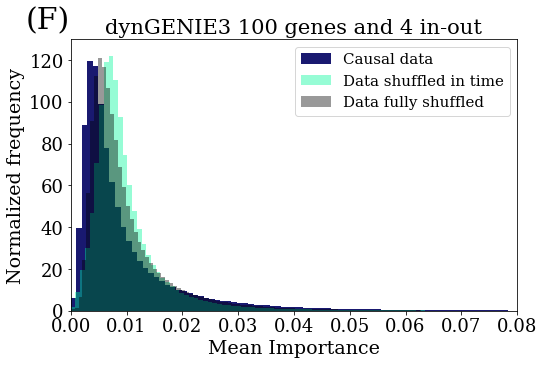

In [5]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_100"], bins = 200, color = "midnightblue", density =1, label = r"Causal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_100"], bins = 200,color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_dynGENIE3["mean_important_array_crand_dynGENIE3_100"], bins = 200,color='k', alpha = 0.4, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 19, family = "serif")
plt.xlabel("Mean Importance", fontsize = 19)
plt.title("dynGENIE3 100 genes and 4 in-out", fontsize = 21)
plt.xlim(0,0.08)
plt.ylim(0,130)
plt.legend(prop={"size":15, "family":"serif"})
plt.text(-0.008,135, "(F)", fontsize = 30)
plt.savefig(f"{file_path_data}/histogram_dynGENIE3_100genes_4degree.png", bbox_inches="tight", dpi=100 )


#Statistics
print("mean: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_100"].mean())
print("mean rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_100"].mean())
print("estandard desv: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_100"].std())
print("estandard desv rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_100"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())